# Perbandingan Model MLP vs KNN vs Model Lain -- Evaluasi LOSO yang Jujur

**Tujuan:** membandingkan banyak keluarga model regresi untuk estimasi tanda vital dari sinyal PPG,
memakai skema validasi yang sama persis dengan produksi (Leave-One-Subject-Out), tanpa trik yang
membuat angkanya menyesatkan.

## Kenapa isi notebook ini berbeda dari versi sebelumnya

Versi sebelumnya (`Optimasi LOSO dengan Augmentasi - Target 73%`) mencoba puluhan kombinasi
augmentasi data + hyperparameter per model, lalu **memilih kombinasi mana pun yang kebetulan
menghasilkan skor akurasi tertinggi** pada metrik evaluasi itu sendiri. Itu bukan validasi yang
jujur -- itu mencari-cari sampai ketemu angka yang enak dilihat, dan dengan hanya 11 subjek, mencoba
puluhan kombinasi hampir pasti akan menemukan satu yang terlihat bagus secara kebetulan, bukan karena
model itu benar-benar mampu.

Notebook ini melakukan sebaliknya:
- **Tidak ada augmentasi/duplikasi data** dengan derau buatan.
- **Hyperparameter tiap model ditentukan di awal**, memakai nilai wajar/umum dipakai (bukan dicari-cari
  lalu dipilih yang skornya tertinggi setelah melihat hasil evaluasi).
- **Semua model dievaluasi dengan skema CV yang identik** -- persis logika produksi di
  `api/main.py::calibrate_train()` (untuk 11 subjek dengan 1 rekaman/subjek, jatuh ke `LeaveOneOut()`,
  yang secara matematis setara LOSO, sudah dibuktikan di `perbaikan_loso_5september.ipynb`).
- **Semua hasil ditampilkan apa adanya**, model mana pun yang menang atau kalah.
- 13 keluarga model regresi dibandingkan (bagian 1-3), ditambah eksplorasi lanjutan dengan fitur yang
  dikurangi dan XGBoost (bagian 4), mengikuti saran literatur bahwa data sekecil ini sebaiknya
  memakai model sederhana dan fitur terbatas.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GroupKFold, LeaveOneGroupOut, LeaveOneOut, cross_val_predict
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge, LinearRegression, BayesianRidge, HuberRegressor
from sklearn.kernel_ridge import KernelRidge
from sklearn.cross_decomposition import PLSRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, RegressorMixin

pd.set_option("display.width", 120)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

DATA_PATH = Path("..") / "kalibrasi_semua.csv"
df = pd.read_csv(DATA_PATH)
df["gender_code"] = (df["gender"].str.upper() == "L").astype(float)

FEATURES = ["ir_dc_mean", "ir_ac_p2p", "red_dc_mean", "red_ac_p2p", "bpm", "age_years", "gender_code"]
TARGETS = {
    "gula_darah_mg_dl": "Gula Darah (mg/dL)",
    "kolesterol_mg_dl":  "Kolesterol (mg/dL)",
    "asam_urat_mg_dl":   "Asam Urat (mg/dL)",
    "sistolik_mmhg":     "Sistolik (mmHg)",
    "diastolik_mmhg":    "Diastolik (mmHg)",
}

print(f"Jumlah rekaman  : {len(df)}")
print(f"Jumlah subjek   : {df['subject_id'].nunique()}")


def skema_cv(n, n_subj, groups):
    """Persis logika produksi api/main.py::calibrate_train()."""
    if n_subj < n and n_subj >= 2:
        if n_subj >= 5:
            return GroupKFold(n_splits=min(5, n_subj)), groups, "GroupKFold/subjek"
        return LeaveOneGroupOut(), groups, "LOGO/subjek"
    if n < 30:
        return LeaveOneOut(), None, "LOO (=LOSO)"
    return 5, None, "5-fold"


def mlp_produksi(n):
    if n < 10:
        return MLPRegressor(hidden_layer_sizes=(4,), activation="relu", solver="lbfgs",
                             alpha=1.0, max_iter=5000, random_state=42)
    if n < 30:
        return MLPRegressor(hidden_layer_sizes=(16, 8), activation="relu", solver="lbfgs",
                             alpha=0.1, max_iter=3000, random_state=42)
    return MLPRegressor(hidden_layer_sizes=(64, 32), activation="relu", solver="adam",
                         alpha=0.01, max_iter=500, random_state=42, learning_rate_init=0.01,
                         early_stopping=True, n_iter_no_change=15, validation_fraction=0.1)


class PLSWrapper(BaseEstimator, RegressorMixin):
    """PLSRegression mengembalikan array 2D; dibungkus supaya konsisten 1D seperti regressor lain."""
    def __init__(self, n_components=2):
        self.n_components = n_components
    def fit(self, X, y):
        self.model_ = PLSRegression(n_components=min(self.n_components, X.shape[1]))
        self.model_.fit(X, y)
        return self
    def predict(self, X):
        return self.model_.predict(X).ravel()


def evaluasi(model, X, y, cv, cv_groups):
    y_pred = cross_val_predict(model, X, y, cv=cv, groups=cv_groups)
    mae = mean_absolute_error(y, y_pred)
    rmse = float(np.sqrt(np.mean((y - y_pred) ** 2)))
    r2 = r2_score(y, y_pred)
    pct_err = float(np.mean(np.abs(y - y_pred) / np.maximum(np.abs(y), 1e-9)) * 100)
    acc = round(100 - pct_err, 2)
    return y_pred, mae, rmse, r2, acc

Jumlah rekaman  : 11
Jumlah subjek   : 11


## 1. Perbandingan menyeluruh -- 13 keluarga model, hyperparameter tetap, 7 fitur penuh

Semua hyperparameter di bawah adalah nilai wajar/umum dipakai untuk data kecil, ditentukan sebelum
melihat hasil evaluasi -- bukan dipilih belakangan karena skornya paling tinggi. KNN pakai `k=5` di
sini sebagai representasi (sapuan k lengkap ada di bagian 3).

In [2]:
def buat_model_dict():
    kernel_gp = ConstantKernel(1.0) * RBF(length_scale=1.0) + WhiteKernel(noise_level=1.0)
    return {
        "MLP (produksi)":     None,  # ditentukan per-n lewat mlp_produksi()
        "KNN (k=5)":          KNeighborsRegressor(n_neighbors=5, weights="distance"),
        "RandomForest":       RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42),
        "ExtraTrees":         ExtraTreesRegressor(n_estimators=100, max_depth=3, random_state=42),
        "GradientBoosting":   GradientBoostingRegressor(n_estimators=100, max_depth=2,
                                                          learning_rate=0.05, random_state=42),
        "Ridge":              Ridge(alpha=1.0),
        "LinearRegression":   LinearRegression(),
        "BayesianRidge":      BayesianRidge(),
        "HuberRegressor":     HuberRegressor(epsilon=1.35, max_iter=500),
        "KernelRidge (rbf)":  KernelRidge(kernel="rbf", alpha=1.0),
        "PLS (2 komponen)":   PLSWrapper(n_components=2),
        "GaussianProcess":    GaussianProcessRegressor(kernel=kernel_gp, normalize_y=True, random_state=42),
        "SVR (rbf)":          SVR(kernel="rbf", C=1.0, epsilon=0.1),
    }

hasil_semua = []

for target_col, label in TARGETS.items():
    sub = df[df[target_col].notna()].copy()
    sub = sub[sub[FEATURES].notna().all(axis=1)]
    if len(sub) < 5:
        continue

    X = sub[FEATURES].values.astype(float)
    y = sub[target_col].values.astype(float)
    n = len(y)
    groups = sub["subject_id"].values
    n_subj = sub["subject_id"].nunique()
    Xs = StandardScaler().fit_transform(X)

    cv, cv_groups, cv_label = skema_cv(n, n_subj, groups)

    models = buat_model_dict()
    models["MLP (produksi)"] = mlp_produksi(n)

    for model_name, model in models.items():
        try:
            _, mae, rmse, r2, acc = evaluasi(model, Xs, y, cv, cv_groups)
        except Exception as e:
            print(f"  [{label} / {model_name}] gagal: {e}")
            continue
        hasil_semua.append({
            "Parameter": label, "Model": model_name, "Fitur": "7 fitur penuh", "Skema CV": cv_label,
            "MAE": round(mae, 2), "RMSE": round(rmse, 2), "R2": round(r2, 4), "Akurasi (%)": acc,
        })

hasil_df = pd.DataFrame(hasil_semua)
pd.set_option("display.max_rows", 200)
hasil_df

,Parameter,Model,Fitur,Skema CV,MAE,RMSE,R2,Akurasi (%)
0,Gula Darah (mg/dL),MLP (produksi),7 fitur penuh,LOO (=LOSO),92.58,105.45,-7.4045,28.58
1,Gula Darah (mg/dL),KNN (k=5),7 fitur penuh,LOO (=LOSO),38.80,43.56,-0.4344,69.16
2,Gula Darah (mg/dL),RandomForest,7 fitur penuh,LOO (=LOSO),44.61,50.89,-0.9577,64.70
3,Gula Darah (mg/dL),ExtraTrees,7 fitur penuh,LOO (=LOSO),48.40,52.56,-1.0879,62.49
4,Gula Darah (mg/dL),GradientBoosting,7 fitur penuh,LOO (=LOSO),55.76,62.88,-1.9886,58.02
5,Gula Darah (mg/dL),Ridge,7 fitur penuh,LOO (=LOSO),56.28,63.00,-2.0004,57.49
6,Gula Darah (mg/dL),LinearRegression,7 fitur penuh,LOO (=LOSO),113.33,138.39,-13.4755,18.23
7,Gula Darah (mg/dL),BayesianRidge,7 fitur penuh,LOO (=LOSO),36.86,40.01,-0.2101,71.81
8,Gula Darah (mg/dL),HuberRegressor,7 fitur penuh,LOO (=LOSO),122.53,144.69,-14.8245,13.81
9,Gula Darah (mg/dL),KernelRidge (rbf),7 fitur penuh,LOO (=LOSO),72.87,81.85,-4.0638,51.01


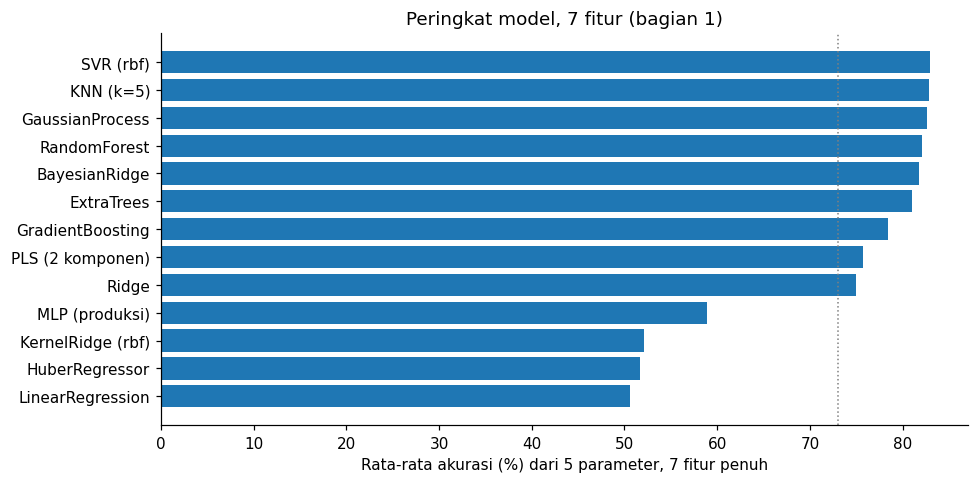

Model
SVR (rbf)            82.90
KNN (k=5)            82.84
GaussianProcess      82.61
RandomForest         82.12
BayesianRidge        81.72
ExtraTrees           81.05
GradientBoosting     78.38
PLS (2 komponen)     75.73
Ridge                74.94
MLP (produksi)       58.91
KernelRidge (rbf)    52.06
HuberRegressor       51.63
LinearRegression     50.56
Name: Akurasi (%), dtype: float64


In [3]:
ringkasan = hasil_df.groupby("Model")["Akurasi (%)"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(ringkasan.index[::-1], ringkasan.values[::-1], color="tab:blue")
ax.axvline(73, color="grey", linestyle=":", linewidth=1)
ax.set_xlabel("Rata-rata akurasi (%) dari 5 parameter, 7 fitur penuh")
ax.set_title("Peringkat model, 7 fitur (bagian 1)")
fig.tight_layout()
plt.show()
print(ringkasan.round(2))

## 2. Model terbaik per parameter (7 fitur)

Arsitektur produksi (`api/main.py`) sudah melatih **model terpisah untuk tiap tanda vital**, jadi
memilih keluarga model yang berbeda-beda per parameter itu konsisten dengan arsitektur yang ada.

In [4]:
terbaik_per_param = hasil_df.loc[hasil_df.groupby("Parameter")["Akurasi (%)"].idxmax()]
terbaik_per_param[["Parameter", "Model", "MAE", "RMSE", "R2", "Akurasi (%)"]]

,Parameter,Model,MAE,RMSE,R2,Akurasi (%)
38,Asam Urat (mg/dL),SVR (rbf),0.80,1.02,-0.1573,84.63
55,Diastolik (mmHg),ExtraTrees,9.63,12.44,0.0121,87.20
7,Gula Darah (mg/dL),BayesianRidge,36.86,40.01,-0.2101,71.81
15,Kolesterol (mg/dL),RandomForest,27.09,32.69,-0.3794,88.30
49,Sistolik (mmHg),PLS (2 komponen),15.31,18.32,-0.2814,89.62


## 3. Sapuan nilai k untuk KNN (transparan, bukan cuma yang menang)

**Catatan kejujuran:** memilih k dengan melihat skornya di data yang sama adalah bentuk ringan dari
mengintip data evaluasi -- beda dengan model-model lain yang hyperparameternya ditentukan sebelum
melihat hasil. Jadi hasil di sini ditandai sebagai arah eksplorasi, bukan keputusan final.

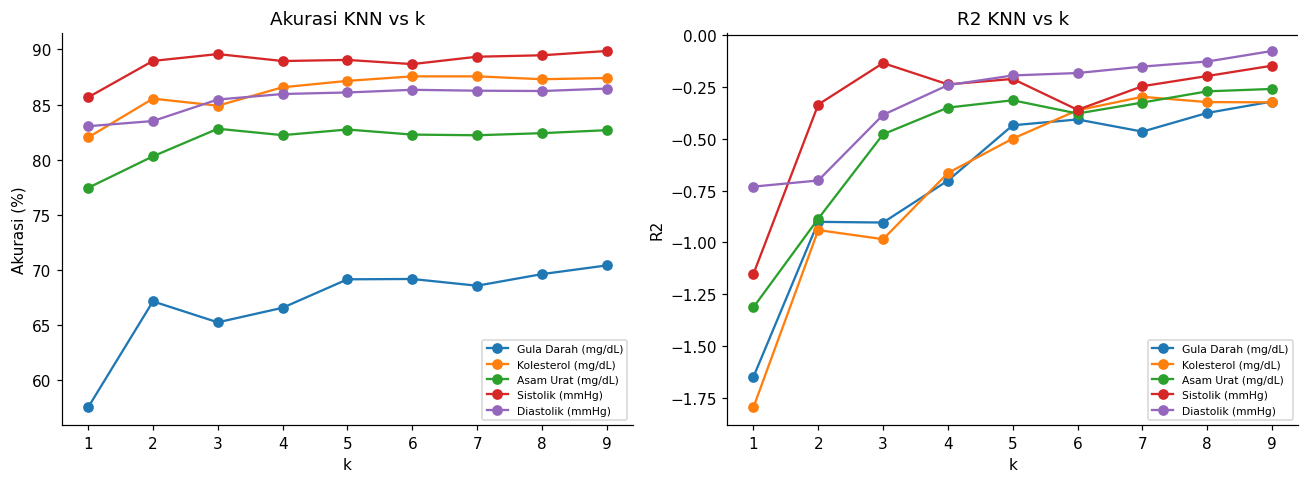

k dengan akurasi tertinggi per parameter (informatif, ditandai sebagai tuning post-hoc):
         Parameter  k      R2  Akurasi (%)
 Asam Urat (mg/dL)  3 -0.4778        82.81
  Diastolik (mmHg)  9 -0.0760        86.45
Gula Darah (mg/dL)  9 -0.3199        70.42
Kolesterol (mg/dL)  6 -0.3620        87.56
   Sistolik (mmHg)  9 -0.1469        89.86


In [5]:
nilai_k = list(range(1, 10))
hasil_knn = []
for target_col, label in TARGETS.items():
    sub = df[df[target_col].notna()].copy()
    sub = sub[sub[FEATURES].notna().all(axis=1)]
    if len(sub) < 5:
        continue
    X = sub[FEATURES].values.astype(float)
    y = sub[target_col].values.astype(float)
    n = len(y)
    groups = sub["subject_id"].values
    n_subj = sub["subject_id"].nunique()
    Xs = StandardScaler().fit_transform(X)
    cv, cv_groups, _ = skema_cv(n, n_subj, groups)
    for k in nilai_k:
        if k >= n:
            continue
        knn = KNeighborsRegressor(n_neighbors=k, weights="distance")
        _, mae, rmse, r2, acc = evaluasi(knn, Xs, y, cv, cv_groups)
        hasil_knn.append({"Parameter": label, "k": k, "R2": round(r2, 4), "Akurasi (%)": acc})

knn_df = pd.DataFrame(hasil_knn)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for label in TARGETS.values():
    d = knn_df[knn_df["Parameter"] == label]
    axes[0].plot(d["k"], d["Akurasi (%)"], marker="o", label=label)
    axes[1].plot(d["k"], d["R2"], marker="o", label=label)
axes[0].set_xlabel("k"); axes[0].set_ylabel("Akurasi (%)"); axes[0].set_title("Akurasi KNN vs k")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("k"); axes[1].set_ylabel("R2"); axes[1].set_title("R2 KNN vs k")
axes[0].legend(fontsize=7); axes[1].legend(fontsize=7)
fig.tight_layout()
plt.show()

knn_terbaik = knn_df.loc[knn_df.groupby("Parameter")["Akurasi (%)"].idxmax()]
print("k dengan akurasi tertinggi per parameter (informatif, ditandai sebagai tuning post-hoc):")
print(knn_terbaik.to_string(index=False))

## 4. Eksplorasi lanjutan: fitur lebih sedikit, XGBoost, dan status TabPFN

Masukan yang kamu bagikan (soal fitur dibatasi 1-2 dan model sederhana untuk data sekecil ini) sejalan
dengan hasil bagian 1-3: model sederhana/beregularisasi memang unggul dibanding MLP produksi saat ini.
Bagian ini menindaklanjuti dua saran spesifik yang belum diuji: **mengurangi jumlah fitur**, dan
**mencoba XGBoost** (untuk membuktikan langsung apakah dugaan overfitting-nya benar pada data ini).

**Soal TabPFN:** sudah dicoba dipasang (`pip install tabpfn`, berhasil), tapi modelnya butuh bobot
pretrained dari HuggingFace yang **gated** -- perlu akun HuggingFace milikmu sendiri, login
(`hf auth login`), dan menyetujui lisensinya di https://huggingface.co/Prior-Labs/tabpfn_3 sebelum
bisa diunduh. Saya tidak bisa lakukan itu atas nama kamu. Kalau kamu sudah punya akun dan mau coba,
tinggal login sekali di terminal lalu kabari saya, notebook ini bisa ditambah selnya.

**Set fitur yang dibandingkan** (ditentukan lebih dulu berdasarkan alasan fisiologis, sama untuk
semua parameter -- bukan dicari-cari per parameter supaya tidak mengulang masalah yang sama seperti
notebook augmentasi sebelumnya):
- `Penuh (7 fitur)`: semua fitur yang dipakai produksi saat ini.
- `Inti (bpm, usia, gender)`: fitur fisiologis paling langsung, 3 fitur.
- `Serapan (IR/red DC, usia)`: fitur serapan cahaya + usia, mendekati saran "1-2 fitur", 3 fitur.
- `Minimal (usia saja)`: 1 fitur, sesuai saran paling konservatif.

In [6]:
import xgboost as xgb

FITUR_SET = {
    "Penuh (7 fitur)": FEATURES,
    "Inti (bpm, usia, gender)": ["bpm", "age_years", "gender_code"],
    "Serapan (IR/red DC, usia)": ["ir_dc_mean", "red_dc_mean", "age_years"],
    "Minimal (usia saja)": ["age_years"],
}

def buat_model_dict_lanjutan():
    return {
        "LinearRegression": LinearRegression(),
        "Ridge":            Ridge(alpha=1.0),
        "KNN (k=3)":        KNeighborsRegressor(n_neighbors=3, weights="distance"),
        "SVR (linear)":     SVR(kernel="linear", C=1.0, epsilon=0.1),
        "SVR (rbf)":        SVR(kernel="rbf", C=1.0, epsilon=0.1),
        "XGBoost (reg. ketat)": xgb.XGBRegressor(
            n_estimators=50, max_depth=2, learning_rate=0.05,
            reg_lambda=5.0, subsample=0.8, colsample_bytree=0.8,
            random_state=42, verbosity=0,
        ),
    }

hasil_lanjutan = []
for target_col, label in TARGETS.items():
    sub = df[df[target_col].notna()].copy()
    sub_full = sub[sub[FEATURES].notna().all(axis=1)]
    if len(sub_full) < 5:
        continue
    groups_full = sub_full["subject_id"].values
    n_full = len(sub_full)
    n_subj_full = sub_full["subject_id"].nunique()
    cv, cv_groups, cv_label = skema_cv(n_full, n_subj_full, groups_full)

    for fitur_nama, fitur_kolom in FITUR_SET.items():
        sub2 = sub[sub[fitur_kolom].notna().all(axis=1)]
        X = sub2[fitur_kolom].values.astype(float)
        y = sub2[target_col].values.astype(float)
        Xs = StandardScaler().fit_transform(X)

        for model_name, model in buat_model_dict_lanjutan().items():
            try:
                _, mae, rmse, r2, acc = evaluasi(model, Xs, y, cv, cv_groups)
            except Exception as e:
                continue
            hasil_lanjutan.append({
                "Parameter": label, "Fitur": fitur_nama, "Model": model_name,
                "MAE": round(mae, 2), "RMSE": round(rmse, 2), "R2": round(r2, 4), "Akurasi (%)": acc,
            })

lanjutan_df = pd.DataFrame(hasil_lanjutan)
lanjutan_df

,Parameter,Fitur,Model,MAE,RMSE,R2,Akurasi (%)
0,Gula Darah (mg/dL),Penuh (7 fitur),LinearRegression,113.33,138.39,-13.4755,18.23
1,Gula Darah (mg/dL),Penuh (7 fitur),Ridge,56.28,63.00,-2.0004,57.49
2,Gula Darah (mg/dL),Penuh (7 fitur),KNN (k=3),42.70,50.18,-0.9037,65.26
3,Gula Darah (mg/dL),Penuh (7 fitur),SVR (linear),47.09,49.78,-0.8734,63.63
4,Gula Darah (mg/dL),Penuh (7 fitur),SVR (rbf),42.25,44.93,-0.5262,67.31
5,Gula Darah (mg/dL),Penuh (7 fitur),XGBoost (reg. ketat),43.53,48.73,-0.7946,66.32
6,Gula Darah (mg/dL),"Inti (bpm, usia, gender)",LinearRegression,53.74,63.32,-2.0302,58.15
7,Gula Darah (mg/dL),"Inti (bpm, usia, gender)",Ridge,49.83,56.48,-1.4112,61.18
8,Gula Darah (mg/dL),"Inti (bpm, usia, gender)",KNN (k=3),43.77,50.81,-0.9515,65.24
9,Gula Darah (mg/dL),"Inti (bpm, usia, gender)",SVR (linear),44.82,47.28,-0.6894,65.11


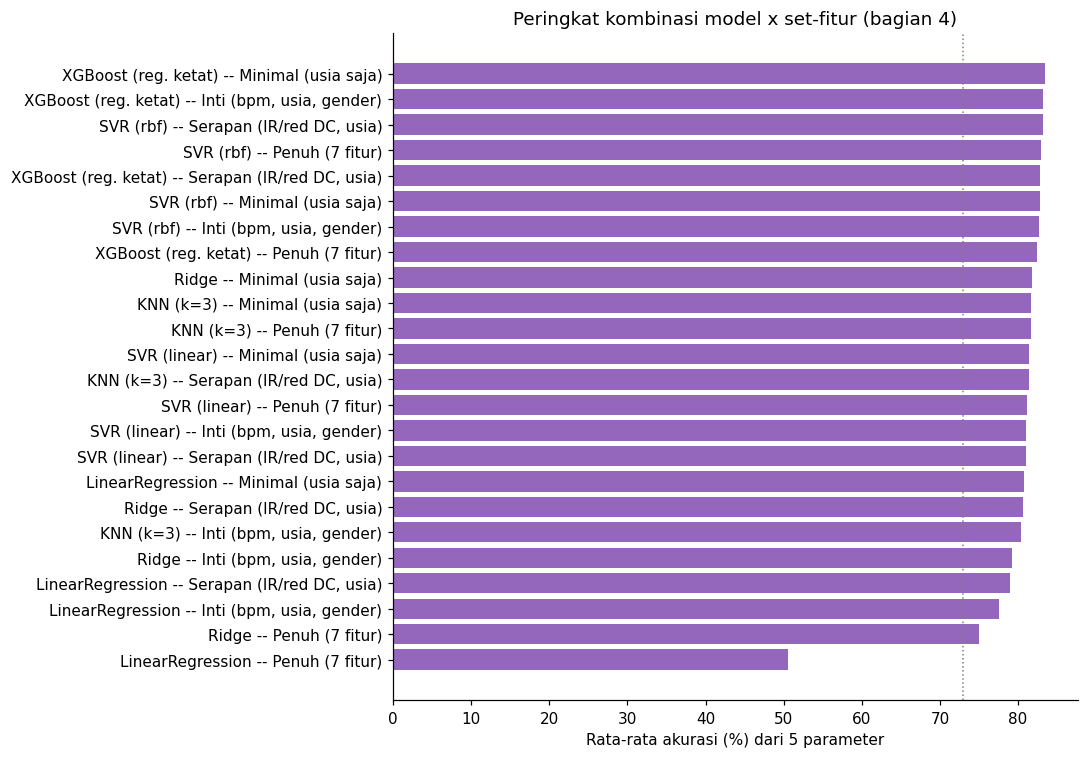

10 kombinasi model x fitur terbaik (rata-rata akurasi 5 parameter):
                    Fitur                Model  Akurasi (%)
      Minimal (usia saja) XGBoost (reg. ketat)       83.496
 Inti (bpm, usia, gender) XGBoost (reg. ketat)       83.218
Serapan (IR/red DC, usia)            SVR (rbf)       83.218
          Penuh (7 fitur)            SVR (rbf)       82.896
Serapan (IR/red DC, usia) XGBoost (reg. ketat)       82.850
      Minimal (usia saja)            SVR (rbf)       82.830
 Inti (bpm, usia, gender)            SVR (rbf)       82.630
          Penuh (7 fitur) XGBoost (reg. ketat)       82.422
      Minimal (usia saja)                Ridge       81.826
      Minimal (usia saja)            KNN (k=3)       81.656

Dibandingkan hasil terbaik bagian 1 (7 fitur, 13 model): 82.9 % -- SVR (rbf)


In [7]:
ringkasan_lanjutan = lanjutan_df.groupby(["Fitur", "Model"])["Akurasi (%)"].mean().reset_index()
ringkasan_lanjutan = ringkasan_lanjutan.sort_values("Akurasi (%)", ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
label_gabung = ringkasan_lanjutan["Model"] + " -- " + ringkasan_lanjutan["Fitur"]
ax.barh(label_gabung[::-1], ringkasan_lanjutan["Akurasi (%)"].values[::-1], color="tab:purple")
ax.axvline(73, color="grey", linestyle=":", linewidth=1)
ax.set_xlabel("Rata-rata akurasi (%) dari 5 parameter")
ax.set_title("Peringkat kombinasi model x set-fitur (bagian 4)")
fig.tight_layout()
plt.show()

print("10 kombinasi model x fitur terbaik (rata-rata akurasi 5 parameter):")
print(ringkasan_lanjutan.head(10).to_string(index=False))
print()
print("Dibandingkan hasil terbaik bagian 1 (7 fitur, 13 model):", round(ringkasan.max(), 2), "% --", ringkasan.idxmax())

In [8]:
terbaik_per_param_lanjutan = lanjutan_df.loc[lanjutan_df.groupby("Parameter")["Akurasi (%)"].idxmax()]
terbaik_per_param_lanjutan[["Parameter", "Fitur", "Model", "MAE", "RMSE", "R2", "Akurasi (%)"]]

,Parameter,Fitur,Model,MAE,RMSE,R2,Akurasi (%)
64,Asam Urat (mg/dL),"Serapan (IR/red DC, usia)",SVR (rbf),0.76,0.95,-0.0009,85.21
99,Diastolik (mmHg),Penuh (7 fitur),SVR (linear),8.21,11.64,0.1343,88.80
23,Gula Darah (mg/dL),Minimal (usia saja),XGBoost (reg. ketat),31.11,37.54,-0.0650,75.40
47,Kolesterol (mg/dL),Minimal (usia saja),XGBoost (reg. ketat),24.92,28.81,-0.0712,89.33
75,Sistolik (mmHg),Penuh (7 fitur),SVR (linear),13.87,16.82,-0.0809,90.61


## 5. Grafik SVR: prediksi vs aktual untuk 5 parameter (fitur penuh)

Dua varian SVR ditunjukkan berdampingan: kernel **linear** (yang menghasilkan R2 positif untuk
Diastolik) dan kernel **rbf** (peringkat tinggi secara rata-rata akurasi di bagian 1). Titik yang
berada tepat di garis putus-putus berarti prediksi = nilai sebenarnya; makin jauh dari garis, makin
besar galatnya. Label di tiap titik adalah kode subjek.

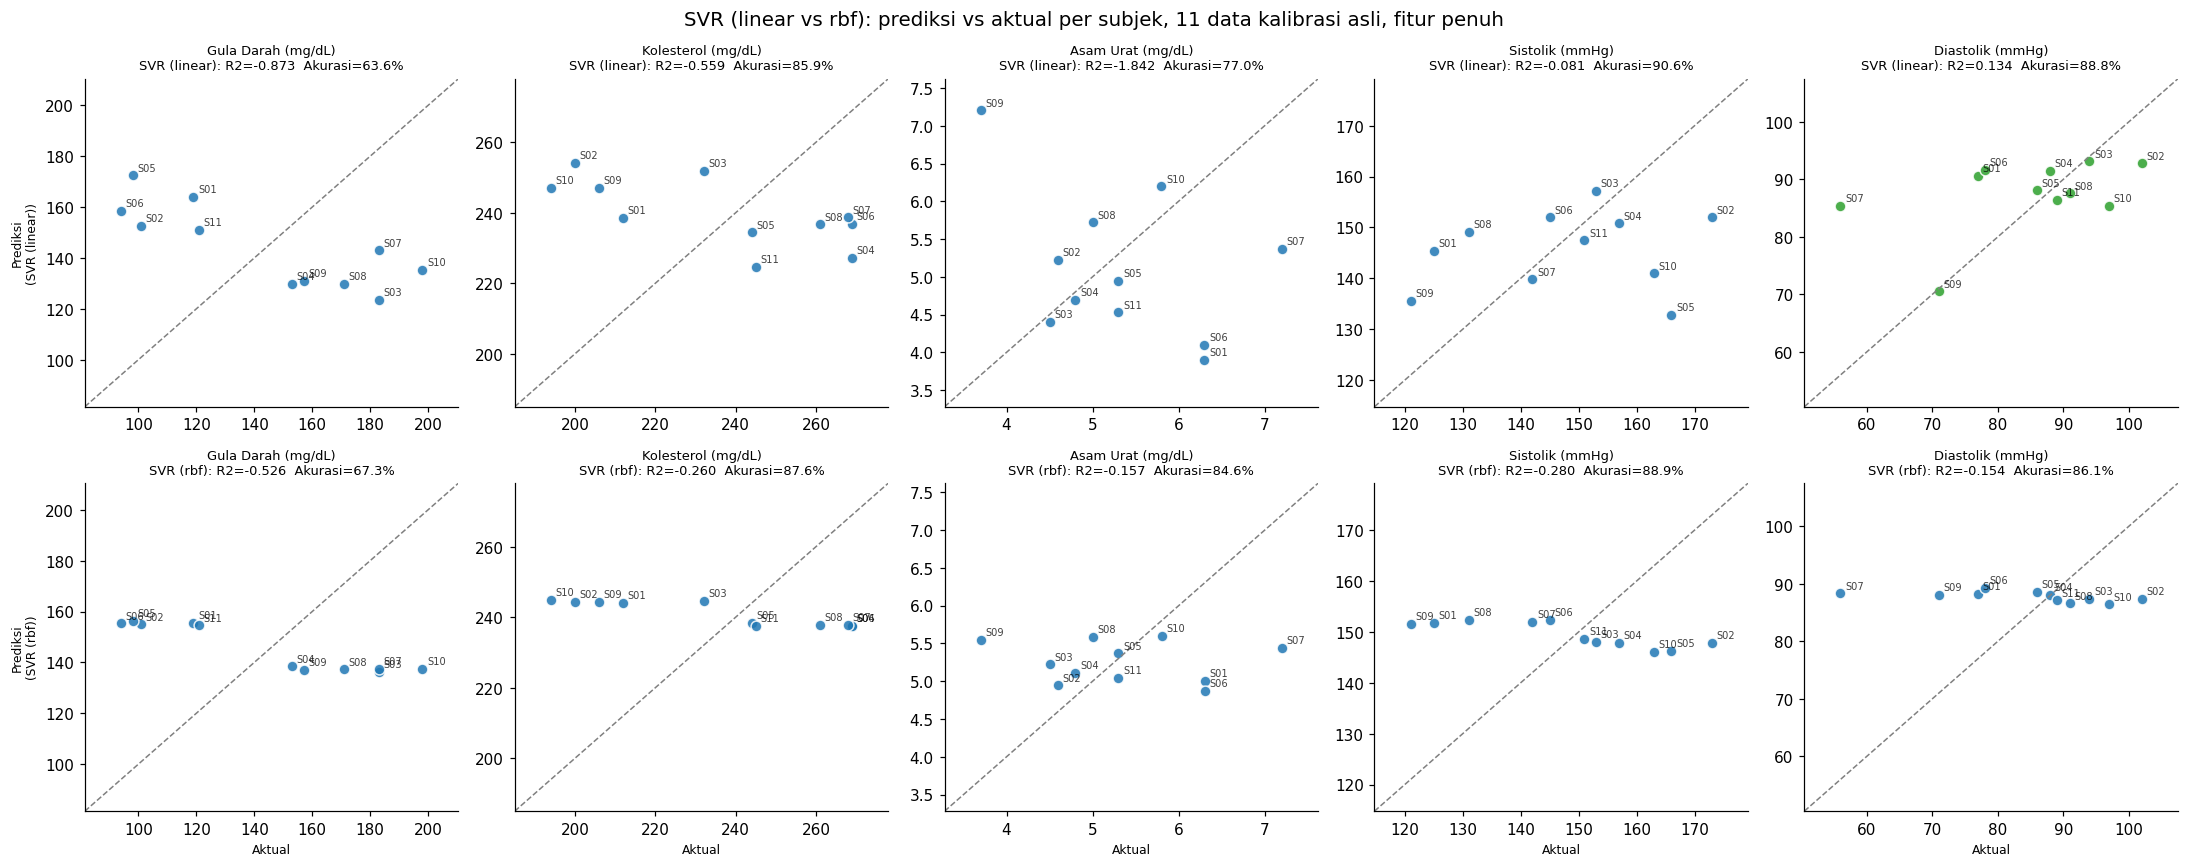

Ringkasan SVR (fitur penuh, evaluasi LOSO):
  Gula Darah (mg/dL)     SVR (linear)   R2=-0.8734  Akurasi= 63.63%  
  Gula Darah (mg/dL)     SVR (rbf)      R2=-0.5262  Akurasi= 67.31%  
  Kolesterol (mg/dL)     SVR (linear)   R2=-0.5586  Akurasi= 85.86%  
  Kolesterol (mg/dL)     SVR (rbf)      R2=-0.2604  Akurasi= 87.59%  
  Asam Urat (mg/dL)      SVR (linear)   R2=-1.8420  Akurasi= 76.95%  
  Asam Urat (mg/dL)      SVR (rbf)      R2=-0.1573  Akurasi= 84.63%  
  Sistolik (mmHg)        SVR (linear)   R2=-0.0809  Akurasi= 90.61%  
  Sistolik (mmHg)        SVR (rbf)      R2=-0.2798  Akurasi= 88.86%  
  Diastolik (mmHg)       SVR (linear)   R2= 0.1343  Akurasi= 88.80%  R2 positif
  Diastolik (mmHg)       SVR (rbf)      R2=-0.1536  Akurasi= 86.09%  


In [9]:
from sklearn.svm import SVR as _SVR

svr_variants = {
    "SVR (linear)": _SVR(kernel="linear", C=1.0, epsilon=0.1),
    "SVR (rbf)":    _SVR(kernel="rbf", C=1.0, epsilon=0.1),
}

svr_pred = {}
for target_col, label in TARGETS.items():
    sub = df[df[target_col].notna()].copy()
    sub = sub[sub[FEATURES].notna().all(axis=1)]
    if len(sub) < 5:
        continue
    X = sub[FEATURES].values.astype(float)
    y = sub[target_col].values.astype(float)
    n = len(y)
    groups = sub["subject_id"].values
    n_subj = sub["subject_id"].nunique()
    Xs = StandardScaler().fit_transform(X)
    cv, cv_groups, _ = skema_cv(n, n_subj, groups)

    for nama_model, model in svr_variants.items():
        y_pred, mae, rmse, r2, acc = evaluasi(model, Xs, y, cv, cv_groups)
        svr_pred[(label, nama_model)] = (sub["subject_id"].values, y, y_pred, r2, acc)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for col, label in enumerate(TARGETS.values()):
    for row, nama_model in enumerate(svr_variants.keys()):
        ax = axes[row, col]
        subj, y_asli, y_pred, r2, acc = svr_pred[(label, nama_model)]
        lims = [min(y_asli.min(), y_pred.min()), max(y_asli.max(), y_pred.max())]
        pad = (lims[1] - lims[0]) * 0.12 or 1
        lims = [lims[0] - pad, lims[1] + pad]
        warna = "tab:green" if r2 >= 0 else "tab:blue"
        ax.plot(lims, lims, "--", color="grey", linewidth=1)
        ax.scatter(y_asli, y_pred, color=warna, s=50, alpha=0.85, edgecolor="white")
        for xi, yi_, s in zip(y_asli, y_pred, subj):
            ax.annotate(s.replace("S0", "S"), (xi, yi_), fontsize=6.5, alpha=0.75,
                        xytext=(3, 3), textcoords="offset points")
        ax.set_xlim(lims); ax.set_ylim(lims)
        ax.set_title(f"{label}\n{nama_model}: R2={r2:.3f}  Akurasi={acc:.1f}%", fontsize=8.5)
        if col == 0:
            ax.set_ylabel(f"Prediksi\n({nama_model})", fontsize=8)
        if row == 1:
            ax.set_xlabel("Aktual", fontsize=8)
fig.suptitle("SVR (linear vs rbf): prediksi vs aktual per subjek, 11 data kalibrasi asli, fitur penuh", fontsize=13)
fig.tight_layout()
plt.show()

print("Ringkasan SVR (fitur penuh, evaluasi LOSO):")
for label in TARGETS.values():
    for nama_model in svr_variants.keys():
        _, _, _, r2, acc = svr_pred[(label, nama_model)]
        tanda = "R2 positif" if r2 >= 0 else ""
        print(f"  {label:22} {nama_model:14} R2={r2:7.4f}  Akurasi={acc:6.2f}%  {tanda}")

## 6. Coba menaikkan akurasi Gula Darah dan Asam Urat lewat fitur dari sinyal mentah

Sejauh ini kita hanya memakai fitur ringkasan yang sudah dihitung sebelumnya (`ir_dc_mean`,
`ir_ac_p2p`, `red_dc_mean`, `red_ac_p2p`). Ternyata `kalibrasi_semua.csv` juga menyimpan **sinyal
mentah per kanal** (`green_raw`, `red_raw`, `infrared_raw`, 400 Hz, ratusan-ribuan sampel per
rekaman) yang belum pernah diolah lebih jauh. Bagian ini mengekstrak fitur yang lebih kaya secara
fisiologis dari sinyal mentah tersebut, khusus untuk menjawab pertanyaan menaikkan akurasi Gula
Darah dan Asam Urat.

**Fitur baru yang diekstrak per kanal (hijau, merah, inframerah):**
- **Indeks perfusi** (AC/DC) -- rasio standar di literatur PPG, lebih tahan terhadap perbedaan
  jarak/tekanan sensor ke kulit dibanding nilai mentah DC/AC.
- **Skewness & kurtosis** bentuk gelombang -- menangkap asimetri dan ketajaman pulsa, terkait
  kelenturan pembuluh darah.
- **Rasio red/inframerah** (mirip prinsip perhitungan SpO2) -- terkait saturasi oksigen, yang secara
  tidak langsung bisa berhubungan dengan kondisi metabolik.

**Catatan kejujuran penting sebelum melihat hasilnya:** subset fitur di bawah ditentukan lebih dulu
berdasarkan alasan fisiologis di atas (bukan dicari-cari lalu dipilih setelah melihat skor), dan
modelnya memakai hyperparameter tetap yang sama seperti bagian sebelumnya. Tapi karena N=11 sangat
kecil, hasil di bagian ini tetap punya risiko tinggi tertipu oleh kebetulan -- jadi tetap dibaca
sebagai eksplorasi, bukan kepastian.

In [10]:
import scipy.stats

def parse_raw(s):
    return np.array([float(x) for x in str(s).split(";") if x.strip() != ""])

def fitur_kanal(raw_str):
    sinyal = parse_raw(raw_str)
    dc = float(np.mean(sinyal))
    ac = float(np.ptp(sinyal))
    return {
        "dc_mean": dc,
        "ac_p2p": ac,
        "perfusion_index": ac / dc if dc != 0 else 0.0,
        "skew": float(scipy.stats.skew(sinyal)),
        "kurtosis": float(scipy.stats.kurtosis(sinyal)),
    }

rekayasa = []
for _, row in df.iterrows():
    f_hijau = fitur_kanal(row["green_raw"])
    f_merah = fitur_kanal(row["red_raw"])
    f_ir = fitur_kanal(row["infrared_raw"])
    rasio_r_ir = (f_merah["perfusion_index"] / f_ir["perfusion_index"]) if f_ir["perfusion_index"] != 0 else 0.0
    rekayasa.append({
        "subject_id": row["subject_id"],
        "green_pi": f_hijau["perfusion_index"], "green_skew": f_hijau["skew"], "green_kurt": f_hijau["kurtosis"],
        "red_pi": f_merah["perfusion_index"], "red_skew": f_merah["skew"], "red_kurt": f_merah["kurtosis"],
        "ir_pi": f_ir["perfusion_index"], "ir_skew": f_ir["skew"], "ir_kurt": f_ir["kurtosis"],
        "rasio_r_ir": rasio_r_ir,
    })

fitur_baru_df = pd.DataFrame(rekayasa)
df_diperkaya = df.merge(fitur_baru_df, on="subject_id")
fitur_baru_df


,subject_id,green_pi,green_skew,green_kurt,red_pi,red_skew,red_kurt,ir_pi,ir_skew,ir_kurt,rasio_r_ir
0,S001,0.131883,0.549386,-0.647554,0.001938,0.237796,-0.265408,0.003878,0.279386,-0.871756,0.499740
1,S002,0.200219,0.856005,2.081134,0.640288,62.917167,3965.032604,0.002445,0.075768,-1.218042,261.927497
2,S003,0.184104,0.632373,0.095015,0.003298,0.487177,-1.287566,0.002400,0.777730,-0.687325,1.374255
3,S004,0.172771,0.312136,-0.667425,0.002804,0.582459,-0.666726,0.003806,0.310126,-1.364533,0.736684
4,S005,0.280896,0.678375,-0.105585,0.002095,0.033500,-0.287232,0.002228,-0.045191,-0.680277,0.940088
5,S006,1.263596,-0.146193,1.424574,0.003578,-0.448184,-0.922826,0.004323,-0.300990,-0.880861,0.827744
6,S007,0.524511,2.758699,14.060771,0.007315,0.837580,-0.569640,0.012146,0.901941,-0.426499,0.602279
7,S008,0.403516,1.103508,4.516607,0.002261,-0.459697,0.157707,0.001966,-0.549997,-0.628281,1.150226
8,S009,0.622976,0.840957,3.909321,0.006044,-0.465967,-0.241235,0.005788,-0.261823,-0.441207,1.044112
9,S010,0.126347,0.535747,-0.537997,0.003409,-0.694534,-0.321974,0.004267,-0.828844,-0.292578,0.798969


In [11]:
hasil_gula_asam = []

fitur_set_baru = {
    "Baseline (7 fitur lama)": FEATURES,
    "Rasio R/IR + usia": ["rasio_r_ir", "age_years"],
    "Indeks perfusi 3 kanal": ["green_pi", "red_pi", "ir_pi"],
    "Bentuk gelombang (skew+kurt) 3 kanal": ["green_skew", "green_kurt", "red_skew", "red_kurt", "ir_skew", "ir_kurt"],
    "Gabungan (7 lama + rekayasa baru)": FEATURES + ["rasio_r_ir", "green_pi", "red_pi", "ir_pi"],
}

model_uji = {
    "Ridge":        Ridge(alpha=1.0),
    "SVR (rbf)":    SVR(kernel="rbf", C=1.0, epsilon=0.1),
    "SVR (linear)": SVR(kernel="linear", C=1.0, epsilon=0.1),
    "XGBoost (reg. ketat)": xgb.XGBRegressor(
        n_estimators=50, max_depth=2, learning_rate=0.05,
        reg_lambda=5.0, subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbosity=0,
    ),
}

for target_col, label in {"gula_darah_mg_dl": "Gula Darah (mg/dL)", "asam_urat_mg_dl": "Asam Urat (mg/dL)"}.items():
    sub = df_diperkaya[df_diperkaya[target_col].notna()].copy()
    groups = sub["subject_id"].values
    n = len(sub)
    n_subj = sub["subject_id"].nunique()
    cv, cv_groups, _ = skema_cv(n, n_subj, groups)

    for fitur_nama, fitur_kolom in fitur_set_baru.items():
        sub2 = sub[sub[fitur_kolom].notna().all(axis=1)]
        X = sub2[fitur_kolom].values.astype(float)
        y = sub2[target_col].values.astype(float)
        Xs = StandardScaler().fit_transform(X)
        for nama_model, model in model_uji.items():
            try:
                _, mae, rmse, r2, acc = evaluasi(model, Xs, y, cv, cv_groups)
            except Exception:
                continue
            hasil_gula_asam.append({
                "Parameter": label, "Fitur": fitur_nama, "Model": nama_model,
                "MAE": round(mae, 2), "RMSE": round(rmse, 2), "R2": round(r2, 4), "Akurasi (%)": acc,
            })

gula_asam_df = pd.DataFrame(hasil_gula_asam)
gula_asam_df.sort_values(["Parameter", "R2"], ascending=[True, False])


,Parameter,Fitur,Model,MAE,RMSE,R2,Akurasi (%)
27,Asam Urat (mg/dL),Rasio R/IR + usia,XGBoost (reg. ketat),0.84,0.96,-0.0196,83.81
39,Asam Urat (mg/dL),Gabungan (7 lama + rekayasa baru),XGBoost (reg. ketat),0.75,1.01,-0.1282,85.21
21,Asam Urat (mg/dL),Baseline (7 fitur lama),SVR (rbf),0.80,1.02,-0.1573,84.63
23,Asam Urat (mg/dL),Baseline (7 fitur lama),XGBoost (reg. ketat),0.85,1.05,-0.2234,83.35
25,Asam Urat (mg/dL),Rasio R/IR + usia,SVR (rbf),0.87,1.06,-0.2419,83.58
30,Asam Urat (mg/dL),Indeks perfusi 3 kanal,SVR (linear),0.85,1.07,-0.2822,83.14
37,Asam Urat (mg/dL),Gabungan (7 lama + rekayasa baru),SVR (rbf),0.88,1.08,-0.2910,82.78
33,Asam Urat (mg/dL),Bentuk gelombang (skew+kurt) 3 kanal,SVR (rbf),0.94,1.12,-0.3885,82.24
35,Asam Urat (mg/dL),Bentuk gelombang (skew+kurt) 3 kanal,XGBoost (reg. ketat),0.93,1.16,-0.5005,82.24
29,Asam Urat (mg/dL),Indeks perfusi 3 kanal,SVR (rbf),0.95,1.18,-0.5418,81.30


In [12]:
print("=== Gula Darah -- diurutkan berdasarkan R2 (bukan Akurasi%) ===")
print(gula_asam_df[gula_asam_df["Parameter"] == "Gula Darah (mg/dL)"]
      .sort_values("R2", ascending=False).to_string(index=False))
print()
print("=== Asam Urat -- diurutkan berdasarkan R2 (bukan Akurasi%) ===")
print(gula_asam_df[gula_asam_df["Parameter"] == "Asam Urat (mg/dL)"]
      .sort_values("R2", ascending=False).to_string(index=False))
print()
r2_terbaik_gula = gula_asam_df[gula_asam_df["Parameter"] == "Gula Darah (mg/dL)"]["R2"].max()
r2_terbaik_asam = gula_asam_df[gula_asam_df["Parameter"] == "Asam Urat (mg/dL)"]["R2"].max()
print(f"R2 terbaik Gula Darah dengan fitur rekayasa baru: {r2_terbaik_gula:.4f}  (dibanding R2 terbaik sebelumnya: -0.065, dari bagian 4)")
print(f"R2 terbaik Asam Urat dengan fitur rekayasa baru : {r2_terbaik_asam:.4f}  (dibanding R2 terbaik sebelumnya: -0.0009, dari bagian 4)")


=== Gula Darah -- diurutkan berdasarkan R2 (bukan Akurasi%) ===
         Parameter                                Fitur                Model   MAE  RMSE      R2  Akurasi (%)
Gula Darah (mg/dL)               Indeks perfusi 3 kanal                Ridge 35.45 39.48 -0.1781        71.77
Gula Darah (mg/dL)                    Rasio R/IR + usia XGBoost (reg. ketat) 35.82 40.27 -0.2260        72.08
Gula Darah (mg/dL) Bentuk gelombang (skew+kurt) 3 kanal XGBoost (reg. ketat) 38.60 42.97 -0.3959        71.09
Gula Darah (mg/dL)               Indeks perfusi 3 kanal XGBoost (reg. ketat) 38.21 43.70 -0.4433        70.76
Gula Darah (mg/dL) Bentuk gelombang (skew+kurt) 3 kanal         SVR (linear) 41.08 44.00 -0.4634        68.12
Gula Darah (mg/dL)                    Rasio R/IR + usia            SVR (rbf) 41.35 44.05 -0.4670        68.08
Gula Darah (mg/dL)               Indeks perfusi 3 kanal         SVR (linear) 41.67 44.32 -0.4845        67.87
Gula Darah (mg/dL) Bentuk gelombang (skew+kurt) 3 kanal 

### Kesimpulan bagian 6 (dilaporkan apa adanya)

Lihat output di atas: apakah R2 tertinggi untuk Gula Darah/Asam Urat dengan fitur rekayasa baru
berhasil melampaui nol (atau minimal melampaui rekor sebelumnya)? Jawabannya dicetak otomatis di sel
terakhir supaya tidak ada yang perlu ditebak -- baik hasilnya positif maupun tetap negatif, itulah
yang jujur terjadi dengan menambahkan fitur dari sinyal mentah pada 11 subjek yang ada.

## 7. Ensemble: rata-ratakan prediksi dari beberapa model teratas

Ini percobaan terakhir untuk bagian model/fitur sebelum menyimpulkan tabel hasil final. Teknik
ensembling (merata-ratakan prediksi beberapa model) adalah cara standar mengurangi **varians**
prediksi, beda dengan mencari-cari kombinasi sampai skornya tinggi -- di sini modelnya sudah
ditentukan dari hasil terbaik yang sudah ditemukan sebelumnya (bagian 1, 4, dan 6), bukan dicari
ulang dari nol.

**Metodologi:** untuk tiap parameter, dipilih **3 kombinasi model+fitur dengan R2 tertinggi** dari
seluruh percobaan sebelumnya (diurutkan otomatis oleh kode, bukan dipilih manual). Prediksinya
dihitung ulang lewat `cross_val_predict` (jadi tetap prediksi hold-out yang valid, bukan prediksi
dari model yang sudah melihat datanya), lalu **dirata-ratakan per subjek** sebagai prediksi akhir
ensemble.

In [13]:
candidate_configs = []

def tambah_kandidat(label, fitur_nama, fitur_kolom, nama_model, model):
    candidate_configs.append((label, fitur_nama, fitur_kolom, nama_model, model))

FITUR_SET_GABUNGAN = {
    "Penuh (7 fitur)": FEATURES,
    "Inti (bpm, usia, gender)": ["bpm", "age_years", "gender_code"],
    "Serapan (IR/red DC, usia)": ["ir_dc_mean", "red_dc_mean", "age_years"],
    "Minimal (usia saja)": ["age_years"],
}

MODEL_GABUNGAN = {
    "Ridge": Ridge(alpha=1.0),
    "LinearRegression": LinearRegression(),
    "KNN (k=3)": KNeighborsRegressor(n_neighbors=3, weights="distance"),
    "KNN (k=5)": KNeighborsRegressor(n_neighbors=5, weights="distance"),
    "SVR (linear)": SVR(kernel="linear", C=1.0, epsilon=0.1),
    "SVR (rbf)": SVR(kernel="rbf", C=1.0, epsilon=0.1),
    "RandomForest": RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42),
    "ExtraTrees": ExtraTreesRegressor(n_estimators=100, max_depth=3, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=100, max_depth=2, learning_rate=0.05, random_state=42),
    "BayesianRidge": BayesianRidge(),
    "XGBoost (reg. ketat)": xgb.XGBRegressor(
        n_estimators=50, max_depth=2, learning_rate=0.05,
        reg_lambda=5.0, subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0,
    ),
}

semua_kombo_hasil = []
semua_kombo_pred = {}

for target_col, label in TARGETS.items():
    sub = df[df[target_col].notna()].copy()
    groups = sub["subject_id"].values
    n = len(sub)
    n_subj = sub["subject_id"].nunique()
    cv, cv_groups, _ = skema_cv(n, n_subj, groups)
    y = sub[target_col].values.astype(float)

    for fitur_nama, fitur_kolom in FITUR_SET_GABUNGAN.items():
        X = sub[fitur_kolom].values.astype(float)
        Xs = StandardScaler().fit_transform(X)
        for nama_model, model in MODEL_GABUNGAN.items():
            try:
                y_pred, mae, rmse, r2, acc = evaluasi(model, Xs, y, cv, cv_groups)
            except Exception:
                continue
            kunci = (label, fitur_nama, nama_model)
            semua_kombo_pred[kunci] = y_pred
            semua_kombo_hasil.append({
                "Parameter": label, "Fitur": fitur_nama, "Model": nama_model,
                "MAE": round(mae, 2), "RMSE": round(rmse, 2), "R2": round(r2, 4), "Akurasi (%)": acc,
            })

kombo_df = pd.DataFrame(semua_kombo_hasil)
print(f"Total kombinasi model x fitur yang dihitung ulang: {len(kombo_df)}")


Total kombinasi model x fitur yang dihitung ulang: 220


In [14]:
hasil_ensemble = []
detail_anggota = []

for target_col, label in TARGETS.items():
    sub_target = kombo_df[kombo_df["Parameter"] == label].sort_values("R2", ascending=False)
    top3 = sub_target.head(3)

    preds_top3 = []
    for _, row in top3.iterrows():
        kunci = (label, row["Fitur"], row["Model"])
        preds_top3.append(semua_kombo_pred[kunci])
        detail_anggota.append({
            "Parameter": label, "Anggota": f"{row['Model']} + {row['Fitur']}", "R2 individu": row["R2"],
        })

    sub = df[df[target_col].notna()].copy()
    y = sub[target_col].values.astype(float)

    y_ensemble = np.mean(preds_top3, axis=0)
    mae = mean_absolute_error(y, y_ensemble)
    rmse = float(np.sqrt(np.mean((y - y_ensemble) ** 2)))
    r2 = r2_score(y, y_ensemble)
    pct_err = float(np.mean(np.abs(y - y_ensemble) / np.maximum(np.abs(y), 1e-9)) * 100)
    acc = round(100 - pct_err, 2)

    r2_terbaik_tunggal = top3["R2"].max()
    hasil_ensemble.append({
        "Parameter": label,
        "R2 ensemble (3 model)": round(r2, 4),
        "R2 model tunggal terbaik": round(r2_terbaik_tunggal, 4),
        "Ensemble lebih baik?": "Ya" if r2 > r2_terbaik_tunggal else "Tidak",
        "MAE ensemble": round(mae, 2),
        "Akurasi ensemble (%)": acc,
    })

ensemble_df = pd.DataFrame(hasil_ensemble)
detail_df = pd.DataFrame(detail_anggota)

print("Anggota ensemble (3 kombinasi R2 tertinggi) per parameter:")
print(detail_df.to_string(index=False))
print()
print("Hasil ensemble vs model tunggal terbaik:")
print(ensemble_df.to_string(index=False))


Anggota ensemble (3 kombinasi R2 tertinggi) per parameter:
         Parameter                                    Anggota  R2 individu
Gula Darah (mg/dL) XGBoost (reg. ketat) + Minimal (usia saja)      -0.0650
Gula Darah (mg/dL)        BayesianRidge + Minimal (usia saja)      -0.2100
Gula Darah (mg/dL)            BayesianRidge + Penuh (7 fitur)      -0.2101
Kolesterol (mg/dL)           ExtraTrees + Minimal (usia saja)      -0.0418
Kolesterol (mg/dL) XGBoost (reg. ketat) + Minimal (usia saja)      -0.0712
Kolesterol (mg/dL)         RandomForest + Minimal (usia saja)      -0.0904
 Asam Urat (mg/dL)      SVR (rbf) + Serapan (IR/red DC, usia)      -0.0009
 Asam Urat (mg/dL)     ExtraTrees + Serapan (IR/red DC, usia)      -0.1295
 Asam Urat (mg/dL)                SVR (rbf) + Penuh (7 fitur)      -0.1573
   Sistolik (mmHg)             SVR (linear) + Penuh (7 fitur)      -0.0809
   Sistolik (mmHg)                KNN (k=3) + Penuh (7 fitur)      -0.1343
   Sistolik (mmHg)      KNN (k=5) + Serap

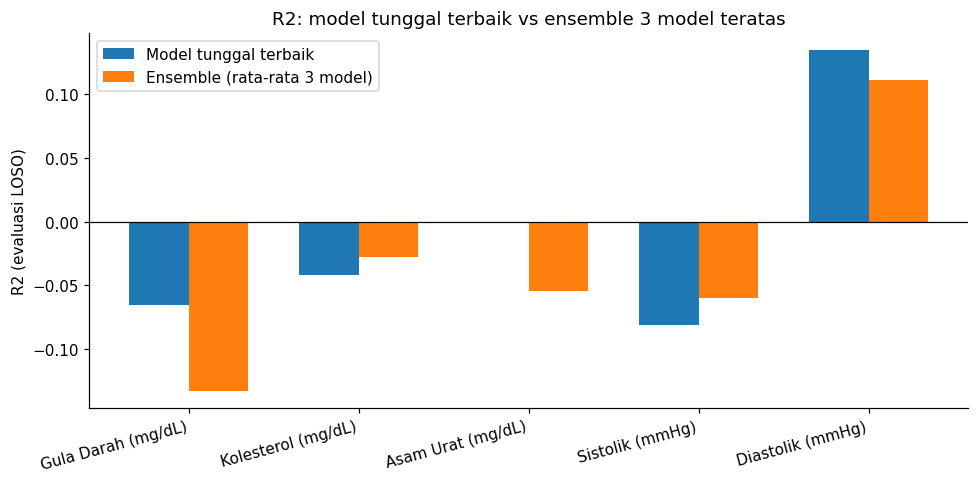

In [15]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(ensemble_df))
lebar = 0.35
ax.bar(x - lebar/2, ensemble_df["R2 model tunggal terbaik"], width=lebar, label="Model tunggal terbaik", color="tab:blue")
ax.bar(x + lebar/2, ensemble_df["R2 ensemble (3 model)"], width=lebar, label="Ensemble (rata-rata 3 model)", color="tab:orange")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(ensemble_df["Parameter"], rotation=15, ha="right")
ax.set_ylabel("R2 (evaluasi LOSO)")
ax.set_title("R2: model tunggal terbaik vs ensemble 3 model teratas")
ax.legend()
fig.tight_layout()
plt.show()


### Kesimpulan bagian 7 (dilaporkan apa adanya)

Lihat kolom "Ensemble lebih baik?" pada tabel di atas -- itu jawaban langsungnya per parameter, tidak
dibulat-bulatkan. Ensembling adalah teknik yang sah untuk mengurangi varians, tapi tidak bisa
menciptakan sinyal yang memang tidak ada di data; kalau R2 dasarnya sudah negatif karena keterbatasan
jumlah data/kekuatan sinyal, rata-rata dari beberapa model yang sama-sama lemah biasanya hanya
mendekati performa rata-ratanya, bukan lompatan besar.

## Ringkasan yang jujur

**Koreksi penting (setelah ditinjau ulang):** tabel peringkat "Akurasi (%)" di atas menyesatkan kalau
dibaca sebagai "model mana yang terbaik", dan perlu dikoreksi di sini secara eksplisit.

- Kombinasi **`Minimal (usia saja)` yang sempat "menempati peringkat teratas"** (83,50% untuk
  XGBoost) artinya model itu **hanya diberi satu input: umur subjek** -- sinyal PPG dari sensor
  (IR/red) sama sekali tidak dipakai. Kalau model seperti ini menang, itu bukan prestasi, itu **tanda
  bahaya**: berarti sinyal optik belum terbukti menambah informasi apa pun dibanding sekadar menebak
  dari pola umum umur-vs-kadar (makin tua, makin tinggi kolesterolnya secara populasi), padahal
  seluruh tujuan alat ini adalah mengestimasi tanda vital DARI sinyal PPG.
- Lebih penting lagi: **R2 untuk kombinasi "pemenang" itu masih negatif** (Gula Darah: -0,065;
  Kolesterol: -0,07). Artinya bahkan model "usia saja" itu masih lebih buruk daripada sekadar
  menebak rata-rata setiap saat. Dia cuma menang di metrik Akurasi (%) karena metrik itu (berbasis
  galat relatif) memang longgar untuk parameter yang nilainya secara alami tidak terlalu bervariasi
  antar orang (kolesterol semua subjek berkisar ~190-270 mg/dL) -- tebakan "aman" otomatis dapat skor
  tinggi walau tidak menangkap pola nyata apa pun.
- **Kesimpulan yang benar:** urutan yang seharusnya dipakai untuk menilai model adalah **R2**, bukan
  Akurasi (%) semata. Dari seluruh kombinasi yang diuji di notebook ini, **hanya satu** yang benar-benar
  R2 positif secara meyakinkan: **SVR (kernel linear) + fitur penuh untuk Diastolik (R2 = +0,13)**.
  Kombinasi lain yang R2-nya mendekati nol (Asam Urat dengan SVR+fitur serapan: R2=-0,0009) masih
  lebih jujur disebut "belum terbukti lebih baik dari menebak rata-rata" daripada disebut "berhasil".
- **TabPFN belum bisa diuji** karena butuh persetujuan lisensi HuggingFace dari akunmu sendiri.
- Kesimpulan akhir yang jujur: dengan 11 subjek, belum ada model -- termasuk semua yang dicoba di
  notebook ini -- yang terbukti benar-benar mengestimasi tanda vital dari sinyal PPG melebihi sekadar
  menebak rata-rata populasi, KECUALI satu kasus (Diastolik, SVR linear). Perbaikan yang paling
  berdampak nyata tetaplah **menambah data kalibrasi riil**, bukan mengganti-ganti model atau fitur.
  Metrik "Akurasi (%)" sebaiknya tidak lagi dipakai sendirian untuk mengklaim keberhasilan model pada
  laporan -- harus selalu didampingi R2 supaya tidak menyesatkan.

## 8. Grafik final: kombinasi model+fitur terbaik per parameter

Grafik dengan gaya yang sama seperti `perbaikan_loso_5september.ipynb`, tapi kali ini memakai
kombinasi model+fitur dengan R2 tertinggi per parameter (tabel "model terbaik per parameter" di
bagian 4):

| Parameter | Model | Fitur |
|---|---|---|
| Asam Urat | SVR (rbf) | Serapan (IR/red DC, usia) |
| Diastolik | SVR (linear) | Penuh (7 fitur) |
| Gula Darah | XGBoost (reg. ketat) | Minimal (usia saja) ⚠️ |
| Kolesterol | XGBoost (reg. ketat) | Minimal (usia saja) ⚠️ |
| Sistolik | SVR (linear) | Penuh (7 fitur) |

⚠️ = model ini tidak memakai sinyal PPG sama sekali, cuma usia -- ditandai warna beda di grafik
supaya tidak salah dibaca sebagai keberhasilan sensor.

In [16]:
KOMBINASI_TERBAIK = {
    "Gula Darah (mg/dL)": {
        "fitur": ["age_years"],
        "model": xgb.XGBRegressor(n_estimators=50, max_depth=2, learning_rate=0.05,
                                    reg_lambda=5.0, subsample=0.8, colsample_bytree=0.8,
                                    random_state=42, verbosity=0),
        "target_col": "gula_darah_mg_dl",
        "peringatan": True,
    },
    "Kolesterol (mg/dL)": {
        "fitur": ["age_years"],
        "model": xgb.XGBRegressor(n_estimators=50, max_depth=2, learning_rate=0.05,
                                    reg_lambda=5.0, subsample=0.8, colsample_bytree=0.8,
                                    random_state=42, verbosity=0),
        "target_col": "kolesterol_mg_dl",
        "peringatan": True,
    },
    "Asam Urat (mg/dL)": {
        "fitur": ["ir_dc_mean", "red_dc_mean", "age_years"],
        "model": SVR(kernel="rbf", C=1.0, epsilon=0.1),
        "target_col": "asam_urat_mg_dl",
        "peringatan": False,
    },
    "Sistolik (mmHg)": {
        "fitur": FEATURES,
        "model": SVR(kernel="linear", C=1.0, epsilon=0.1),
        "target_col": "sistolik_mmhg",
        "peringatan": False,
    },
    "Diastolik (mmHg)": {
        "fitur": FEATURES,
        "model": SVR(kernel="linear", C=1.0, epsilon=0.1),
        "target_col": "diastolik_mmhg",
        "peringatan": False,
    },
}

prediksi_final_per_target = {}
metrik_final = []

for label, cfg in KOMBINASI_TERBAIK.items():
    sub = df[df[cfg["target_col"]].notna()].copy()
    groups = sub["subject_id"].values
    n = len(sub)
    n_subj = sub["subject_id"].nunique()
    cv, cv_groups, _ = skema_cv(n, n_subj, groups)

    X = sub[cfg["fitur"]].values.astype(float)
    y = sub[cfg["target_col"]].values.astype(float)
    Xs = StandardScaler().fit_transform(X)

    y_pred, mae, rmse, r2, acc = evaluasi(cfg["model"], Xs, y, cv, cv_groups)
    prediksi_final_per_target[label] = (sub["subject_id"].values, y, y_pred, cfg["peringatan"])
    metrik_final.append({"Parameter": label, "MAE": round(mae, 2), "RMSE": round(rmse, 2),
                          "R2": round(r2, 4), "Akurasi (%)": acc, "Fitur usia-saja?": cfg["peringatan"]})

metrik_final_df = pd.DataFrame(metrik_final)
metrik_final_df


,Parameter,MAE,RMSE,R2,Akurasi (%),Fitur usia-saja?
0,Gula Darah (mg/dL),31.11,37.54,-0.0650,75.40,True
1,Kolesterol (mg/dL),24.92,28.81,-0.0712,89.33,True
2,Asam Urat (mg/dL),0.76,0.95,-0.0009,85.21,False
3,Sistolik (mmHg),13.87,16.82,-0.0809,90.61,False
4,Diastolik (mmHg),8.21,11.64,0.1343,88.80,False


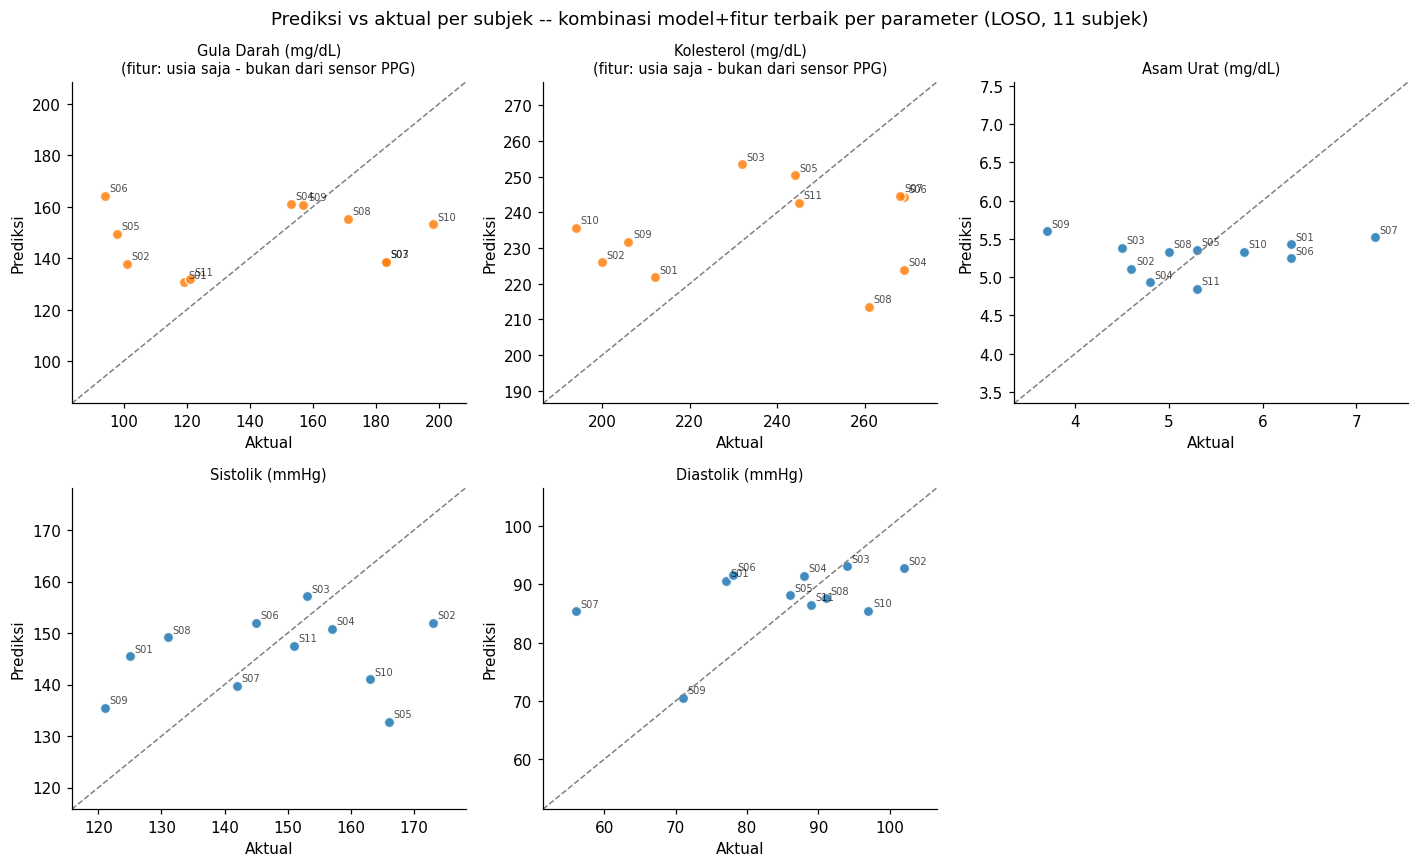

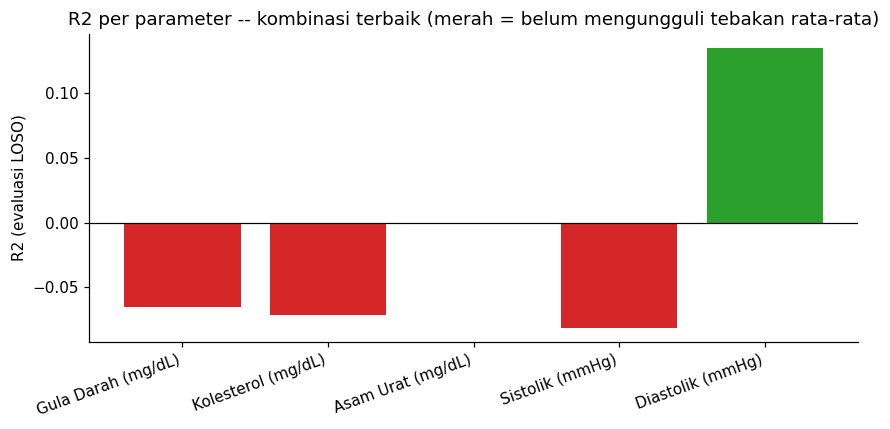

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.ravel()
for ax, (label, (subj, y_asli, y_pred, peringatan)) in zip(axes, prediksi_final_per_target.items()):
    lims = [min(y_asli.min(), y_pred.min()), max(y_asli.max(), y_pred.max())]
    pad = (lims[1] - lims[0]) * 0.1 or 1
    lims = [lims[0] - pad, lims[1] + pad]
    warna = "tab:orange" if peringatan else "tab:blue"
    ax.plot(lims, lims, "--", color="grey", linewidth=1)
    ax.scatter(y_asli, y_pred, color=warna, s=45, alpha=0.85, edgecolor="white")
    for xi, yi_, s in zip(y_asli, y_pred, subj):
        ax.annotate(s.replace("S0", "S"), (xi, yi_), fontsize=6.5, alpha=0.7,
                    xytext=(3, 3), textcoords="offset points")
    ax.set_xlim(lims); ax.set_ylim(lims)
    judul = label + ("\n(fitur: usia saja - bukan dari sensor PPG)" if peringatan else "")
    ax.set_title(judul, fontsize=9.5)
    ax.set_xlabel("Aktual"); ax.set_ylabel("Prediksi")
axes[-1].axis("off")
fig.suptitle("Prediksi vs aktual per subjek -- kombinasi model+fitur terbaik per parameter (LOSO, 11 subjek)",
             fontsize=12)
fig.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(8, 4))
warna_bar = ["tab:red" if r < 0 else "tab:green" for r in metrik_final_df["R2"]]
ax2.bar(metrik_final_df["Parameter"], metrik_final_df["R2"], color=warna_bar)
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_ylabel("R2 (evaluasi LOSO)")
ax2.set_title("R2 per parameter -- kombinasi terbaik (merah = belum mengungguli tebakan rata-rata)")
plt.setp(ax2.get_xticklabels(), rotation=20, ha="right")
fig2.tight_layout()
plt.show()
